# **Importing libraries**

In [158]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model  import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import VotingClassifier
from sklearn.metrics import accuracy_score,roc_auc_score,classification_report

# **Load Dataset**

In [24]:
emp_data = pd.read_csv(r"D:\Projects\train.csv")

# **Exploring dataset**

In [26]:
emp_data.head()

,Employee ID,Age,Gender,Years at Company,Job Role,Monthly Income,Work-Life Balance,Job Satisfaction,Performance Rating,Number of Promotions,...,Number of Dependents,Job Level,Company Size,Company Tenure,Remote Work,Leadership Opportunities,Innovation Opportunities,Company Reputation,Employee Recognition,Attrition
0,8410,31,Male,19,Education,5390,Excellent,Medium,Average,2,...,0,Mid,Medium,89,No,No,No,Excellent,Medium,Stayed
1,64756,59,Female,4,Media,5534,Poor,High,Low,3,...,3,Mid,Medium,21,No,No,No,Fair,Low,Stayed
2,30257,24,Female,10,Healthcare,8159,Good,High,Low,0,...,3,Mid,Medium,74,No,No,No,Poor,Low,Stayed
3,65791,36,Female,7,Education,3989,Good,High,High,1,...,2,Mid,Small,50,Yes,No,No,Good,Medium,Stayed
4,65026,56,Male,41,Education,4821,Fair,Very High,Average,0,...,0,Senior,Medium,68,No,No,No,Fair,Medium,Stayed


In [28]:
emp_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 59598 entries, 0 to 59597
Data columns (total 24 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Employee ID               59598 non-null  int64 
 1   Age                       59598 non-null  int64 
 2   Gender                    59598 non-null  object
 3   Years at Company          59598 non-null  int64 
 4   Job Role                  59598 non-null  object
 5   Monthly Income            59598 non-null  int64 
 6   Work-Life Balance         59598 non-null  object
 7   Job Satisfaction          59598 non-null  object
 8   Performance Rating        59598 non-null  object
 9   Number of Promotions      59598 non-null  int64 
 10  Overtime                  59598 non-null  object
 11  Distance from Home        59598 non-null  int64 
 12  Education Level           59598 non-null  object
 13  Marital Status            59598 non-null  object
 14  Number of Dependents  

In [30]:
emp_data.isna().sum()

Employee ID                 0
Age                         0
Gender                      0
Years at Company            0
Job Role                    0
Monthly Income              0
Work-Life Balance           0
Job Satisfaction            0
Performance Rating          0
Number of Promotions        0
Overtime                    0
Distance from Home          0
Education Level             0
Marital Status              0
Number of Dependents        0
Job Level                   0
Company Size                0
Company Tenure              0
Remote Work                 0
Leadership Opportunities    0
Innovation Opportunities    0
Company Reputation          0
Employee Recognition        0
Attrition                   0
dtype: int64

In [32]:
emp_data.describe()

,Employee ID,Age,Years at Company,Monthly Income,Number of Promotions,Distance from Home,Number of Dependents,Company Tenure
count,59598.000000,59598.000000,59598.000000,59598.000000,59598.000000,59598.000000,59598.000000,59598.000000
mean,37227.118729,38.565875,15.753901,7302.397983,0.832578,50.007651,1.648075,55.758415
std,21519.150028,12.079673,11.245981,2151.457423,0.994991,28.466459,1.555689,25.411090
min,1.000000,18.000000,1.000000,1316.000000,0.000000,1.000000,0.000000,2.000000
25%,18580.250000,28.000000,7.000000,5658.000000,0.000000,25.000000,0.000000,36.000000
50%,37209.500000,39.000000,13.000000,7354.000000,1.000000,50.000000,1.000000,56.000000
75%,55876.750000,49.000000,23.000000,8880.000000,2.000000,75.000000,3.000000,76.000000
max,74498.000000,59.000000,51.000000,16149.000000,4.000000,99.000000,6.000000,128.000000


In [34]:
emp_data.shape

(59598, 24)

In [40]:
emp_data.nunique()

Employee ID                 59598
Age                            42
Gender                          2
Years at Company               51
Job Role                        5
Monthly Income               9569
Work-Life Balance               4
Job Satisfaction                4
Performance Rating              4
Number of Promotions            5
Overtime                        2
Distance from Home             99
Education Level                 5
Marital Status                  3
Number of Dependents            7
Job Level                       3
Company Size                    3
Company Tenure                127
Remote Work                     2
Leadership Opportunities        2
Innovation Opportunities        2
Company Reputation              4
Employee Recognition            4
Attrition                       2
dtype: int64

In [45]:
num_cols = emp_data.select_dtypes(exclude =['object']).columns
cat_cols = emp_data.select_dtypes(include =['object']).columns

# **Exploratory data analysis**

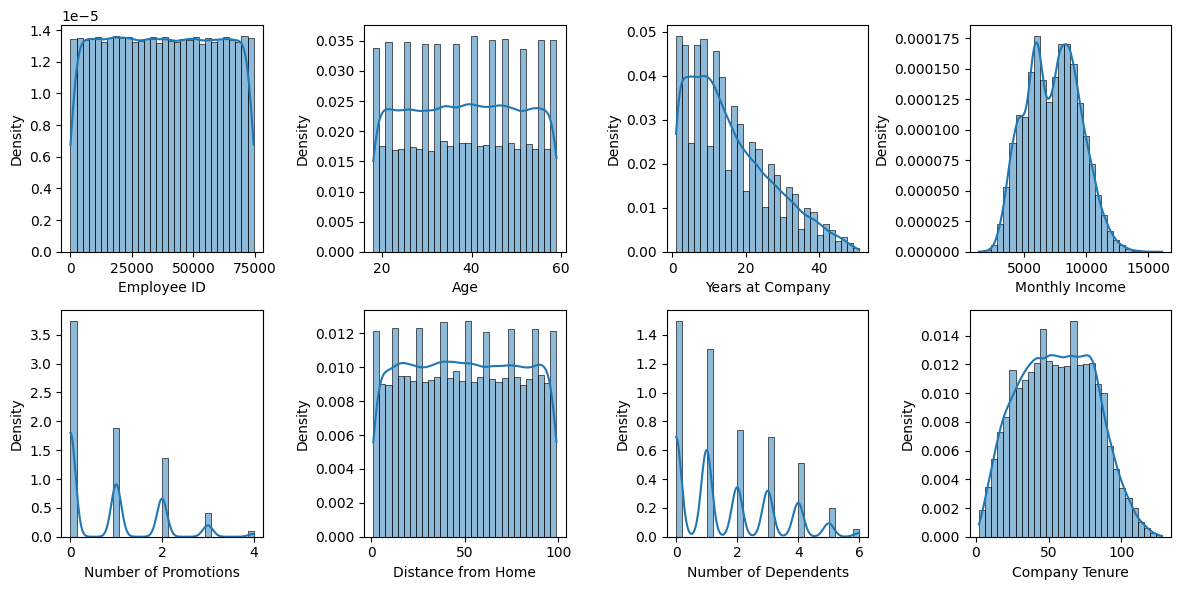

In [51]:
fig,ax = plt.subplots(2,4,figsize=(12,6))
ax = ax.flatten()

for i,col in enumerate(num_cols):
    sns.histplot(emp_data[col],kde =  True, bins = 30, stat = 'density',ax = ax[i])
plt.tight_layout()
plt.show()

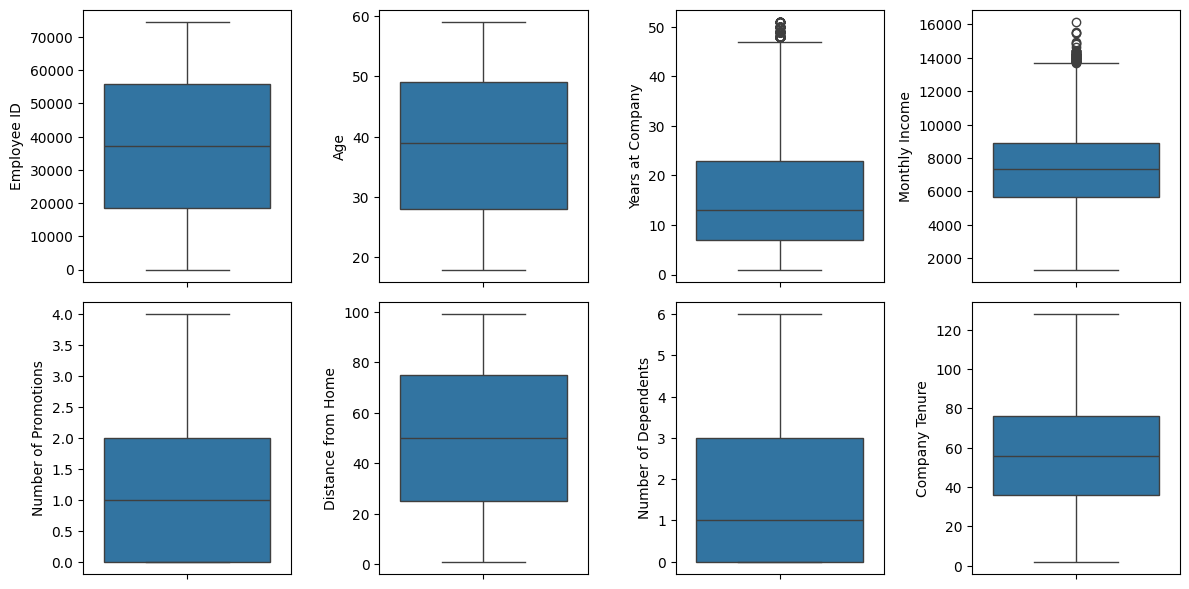

In [53]:
fig,ax = plt.subplots(2,4,figsize=(12,6))
ax = ax.flatten()

for i,col in enumerate(num_cols):
    sns.boxplot(emp_data[col], ax = ax[i])
plt.tight_layout()
plt.show()

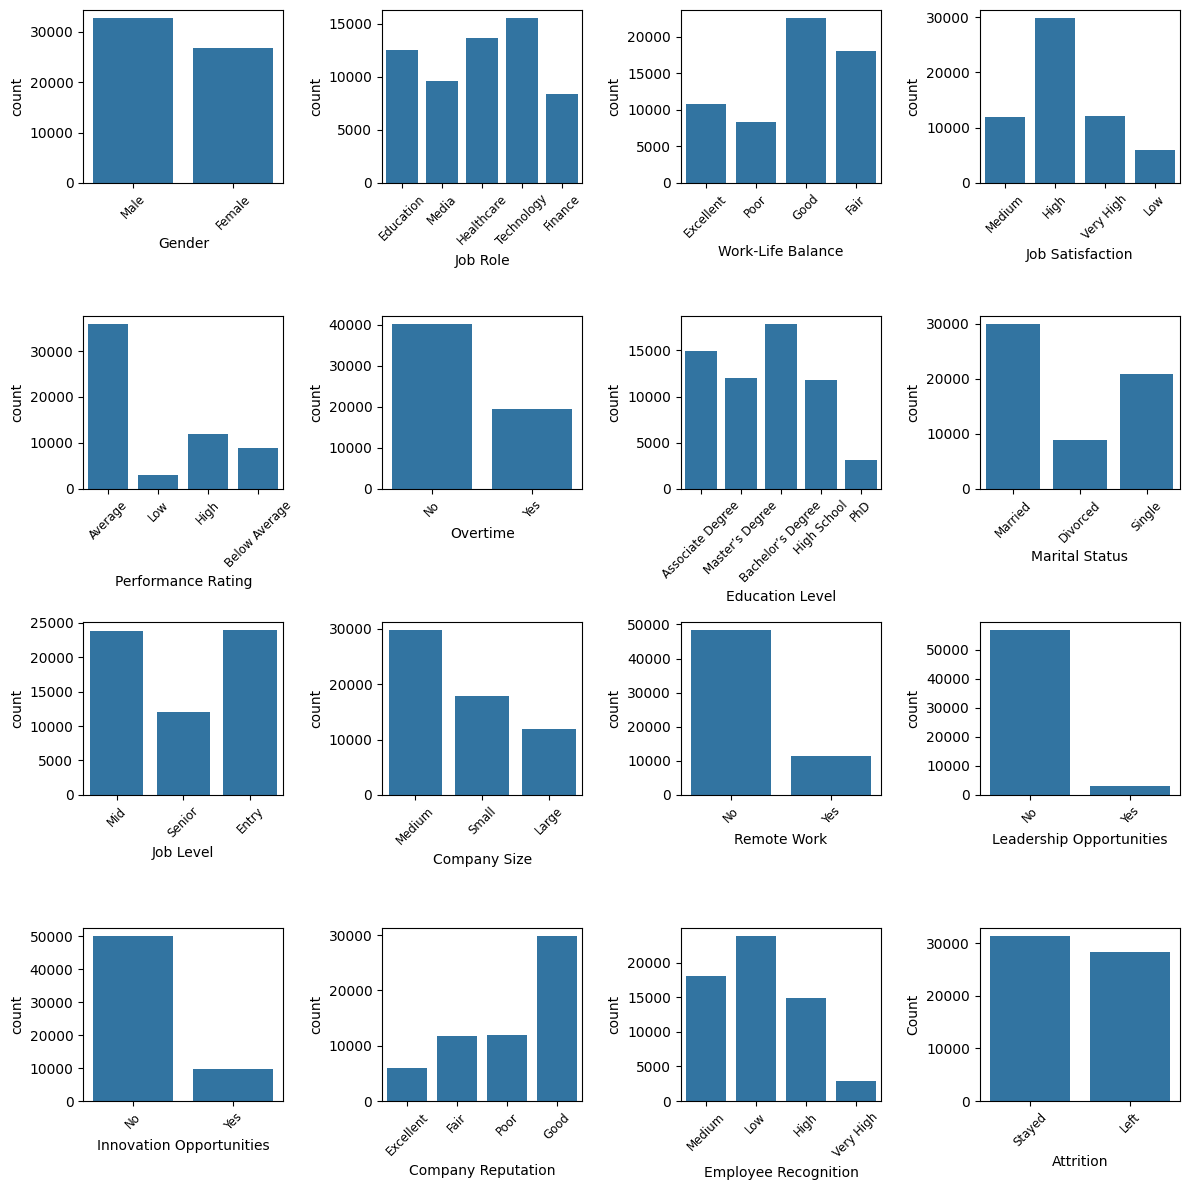

In [67]:
fig,ax = plt.subplots(4,4,figsize=(12,12))
ax = ax.flatten()

for i,col in enumerate(cat_cols):
    sns.countplot(data = emp_data, x = col, ax = ax[i])
    plt.ylabel('Count')
    ax[i].tick_params(axis = 'x',rotation = 45, labelsize = 8.5)
plt.tight_layout()
plt.show()

# **Splitting Dataset**

In [70]:
df_encoded = pd.get_dummies(emp_data, columns=cat_cols, drop_first=True)

In [74]:
df_encoded

,Employee ID,Age,Years at Company,Monthly Income,Number of Promotions,Distance from Home,Number of Dependents,Company Tenure,Gender_Male,Job Role_Finance,...,Remote Work_Yes,Leadership Opportunities_Yes,Innovation Opportunities_Yes,Company Reputation_Fair,Company Reputation_Good,Company Reputation_Poor,Employee Recognition_Low,Employee Recognition_Medium,Employee Recognition_Very High,Attrition_Stayed
0,8410,31,19,5390,2,22,0,89,True,False,...,False,False,False,False,False,False,False,True,False,True
1,64756,59,4,5534,3,21,3,21,False,False,...,False,False,False,True,False,False,True,False,False,True
2,30257,24,10,8159,0,11,3,74,False,False,...,False,False,False,False,False,True,True,False,False,True
3,65791,36,7,3989,1,27,2,50,False,False,...,True,False,False,False,True,False,False,True,False,True
4,65026,56,41,4821,0,71,0,68,True,False,...,False,False,False,True,False,False,False,True,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
59593,37195,50,12,4414,1,66,2,35,False,False,...,False,False,True,False,False,True,False,False,True,False
59594,6266,18,4,8040,3,42,0,73,True,False,...,False,False,False,True,False,False,False,True,False,False
59595,54887,22,14,7944,0,34,2,29,False,False,...,False,True,False,False,True,False,False,True,False,True
59596,861,23,8,2931,0,62,0,9,True,False,...,False,False,False,False,True,False,True,False,False,False


In [103]:
X = df_encoded.drop('Attrition_Stayed', axis=1)
y = df_encoded['Attrition_Stayed']

In [105]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size = 0.2,random_state=42)

# **Model Training**

# **Logistic Regression**

In [97]:
model = LogisticRegression(max_iter=2000)

In [107]:
model.fit(X_train, y_train)

LogisticRegression(max_iter=2000)

In [109]:
# Predictions
y_pred = model.predict(X_test)

In [111]:
# Evaluation
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.2f}")

Accuracy: 0.74


In [117]:
print("Classification Report:")
print(classification_report(y_test, y_pred))

Classification Report:
              precision    recall  f1-score   support

       False       0.73      0.72      0.72      5667
        True       0.75      0.75      0.75      6253

    accuracy                           0.74     11920
   macro avg       0.74      0.74      0.74     11920
weighted avg       0.74      0.74      0.74     11920



 # **DecisionTreeClassifier**

In [132]:
classifier = DecisionTreeClassifier(random_state=42)
classifier.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

In [134]:
#predict and evaluate
y_pred = classifier.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy:{accuracy:.2f}")

Accuracy:0.66


In [136]:
classifier = DecisionTreeClassifier(criterion='gini', max_depth=4, random_state=42)
classifier.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=4, random_state=42)

In [138]:

# Predict on the test set
y_pred = classifier.predict(X_test)

In [140]:
# Classification report
class_report = classification_report(y_test, y_pred)
print('Classification Report:')
print(class_report)

Classification Report:
              precision    recall  f1-score   support

       False       0.69      0.69      0.69      5667
        True       0.72      0.71      0.72      6253

    accuracy                           0.70     11920
   macro avg       0.70      0.70      0.70     11920
weighted avg       0.70      0.70      0.70     11920



In [142]:
# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.2f}")

Accuracy: 0.70


In [144]:
# Initialize and train the Decision Tree Classifier
classifier = DecisionTreeClassifier(criterion='entropy', max_depth=4, random_state=42)
classifier.fit(X_train, y_train)

DecisionTreeClassifier(criterion='entropy', max_depth=4, random_state=42)

In [146]:
# Predict on the test set
y_pred = classifier.predict(X_test)

In [148]:
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.2f}")

Accuracy: 0.70


In [150]:
print("Classification Report:")
print(classification_report(y_test, y_pred))

Classification Report:
              precision    recall  f1-score   support

       False       0.69      0.69      0.69      5667
        True       0.72      0.71      0.72      6253

    accuracy                           0.70     11920
   macro avg       0.70      0.70      0.70     11920
weighted avg       0.70      0.70      0.70     11920



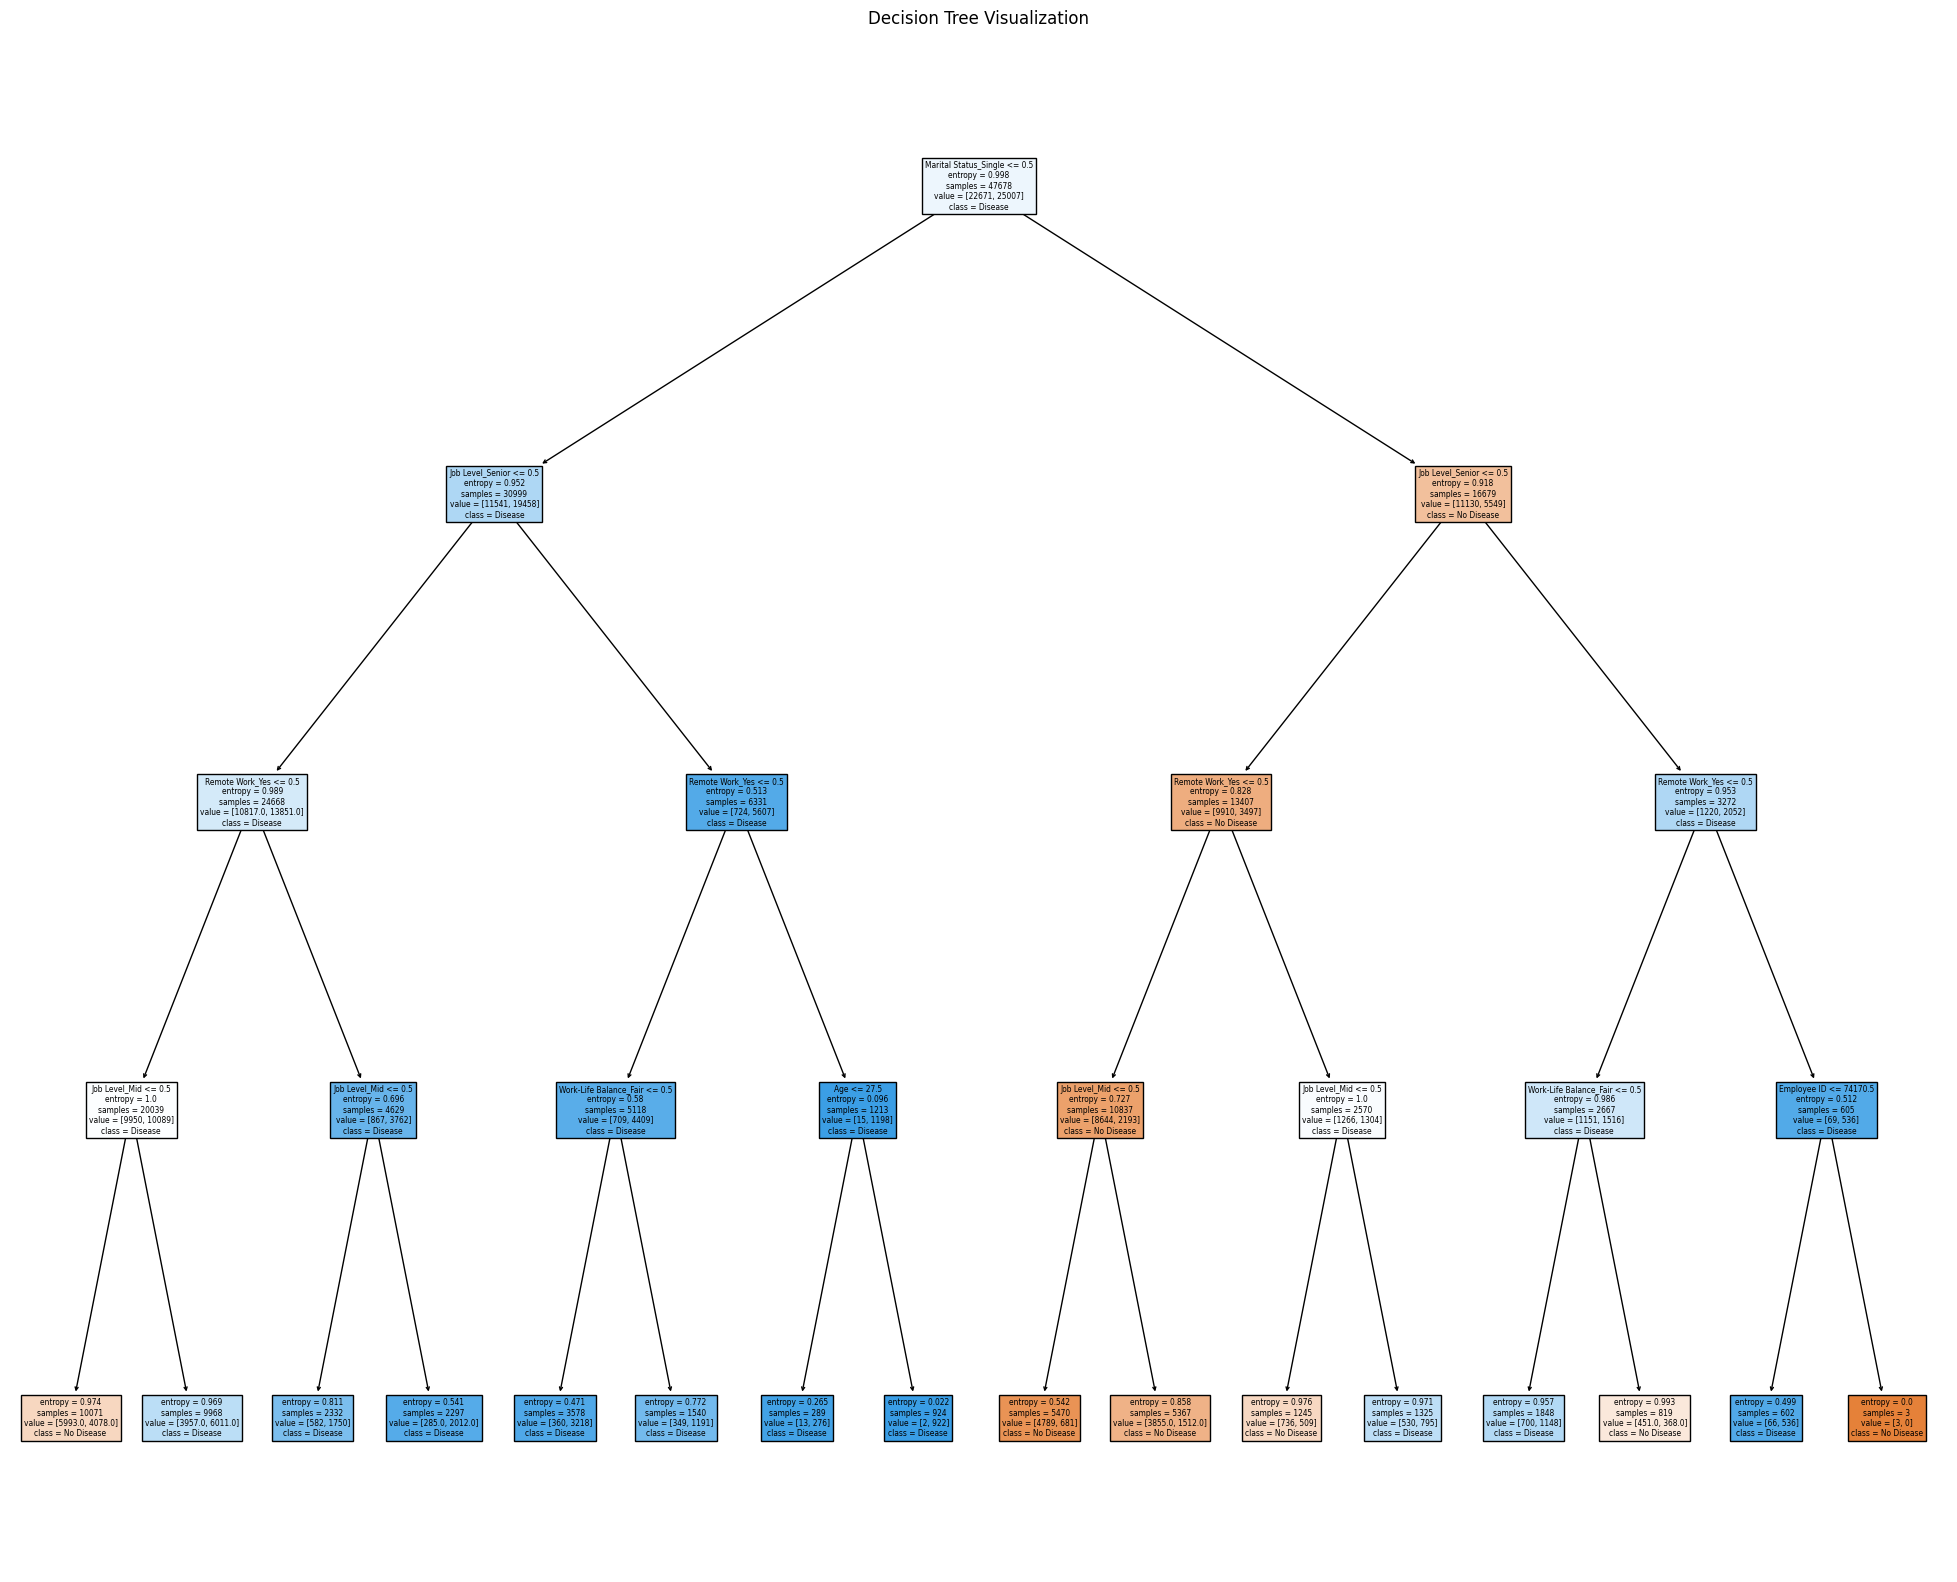

In [152]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import tree 
%matplotlib inline
plt.figure(figsize=(25, 20))
tree.plot_tree(classifier,
               feature_names=X.columns,
               class_names=['No Disease', 'Disease'],
               filled=True)
plt.title('Decision Tree Visualization')
plt.show()

In [154]:
# Initialize individual models
log_clf = LogisticRegression(max_iter=1000, random_state=42)
dt_clf = DecisionTreeClassifier(random_state=42)

In [162]:
# Create a voting classifier using these models
voting_clf = VotingClassifier(
    estimators=[('log_reg', log_clf), ('decision_tree', dt_clf)],
    voting='hard'  # or 'soft' for probability-based voting
)

In [164]:
# Fit the voting classifier to the training data
voting_clf.fit(X_train, y_train)

VotingClassifier(estimators=[('log_reg',
                              LogisticRegression(max_iter=1000,
                                                 random_state=42)),
                             ('decision_tree',
                              DecisionTreeClassifier(random_state=42))])

In [166]:
# Predict and evaluate
y_pred = voting_clf.predict(X_test)
print("Ensemble Voting Classifier Accuracy:", accuracy_score(y_test, y_pred))

Ensemble Voting Classifier Accuracy: 0.6963087248322147


In [168]:
# Individual model performance for comparison
for clf in (log_clf, dt_clf, voting_clf):
    clf.fit(X_train, y_train)
    y_pred_individual = clf.predict(X_test)
    print(clf.__class__.__name__, "Accuracy:", accuracy_score(y_test, y_pred_individual))

LogisticRegression Accuracy: 0.7270973154362416
DecisionTreeClassifier Accuracy: 0.662751677852349
VotingClassifier Accuracy: 0.6963087248322147
